In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Carga de datos procesados
customers = pd.read_csv('../data/processed/customers_clean.csv')
articles = pd.read_csv('../data/processed/articles_clean.csv')
transactions = pd.read_csv('../data/processed/transactions_sample.csv', parse_dates=['t_dat'])

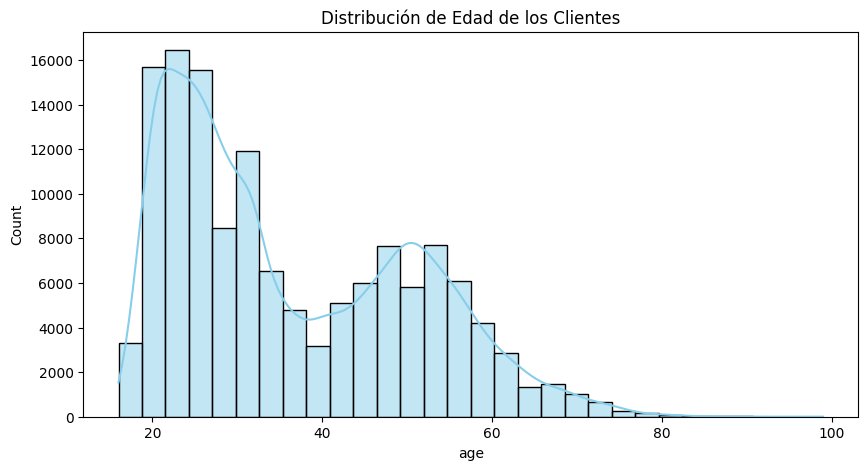

C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_16196\984763418.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='club_member_status', data=customers, palette='viridis')


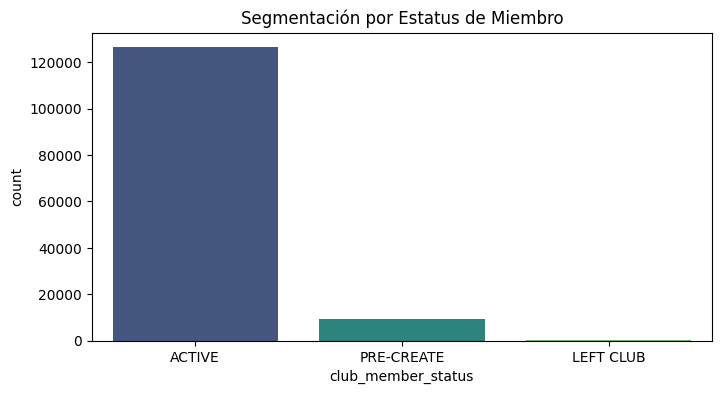

In [6]:
# Histograma de edades
plt.figure(figsize=(10, 5))
sns.histplot(customers['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Edad de los Clientes')
plt.show()

# Estatus de membresía
plt.figure(figsize=(8, 4))
sns.countplot(x='club_member_status', data=customers, palette='viridis')
plt.title('Segmentación por Estatus de Miembro')
plt.show()

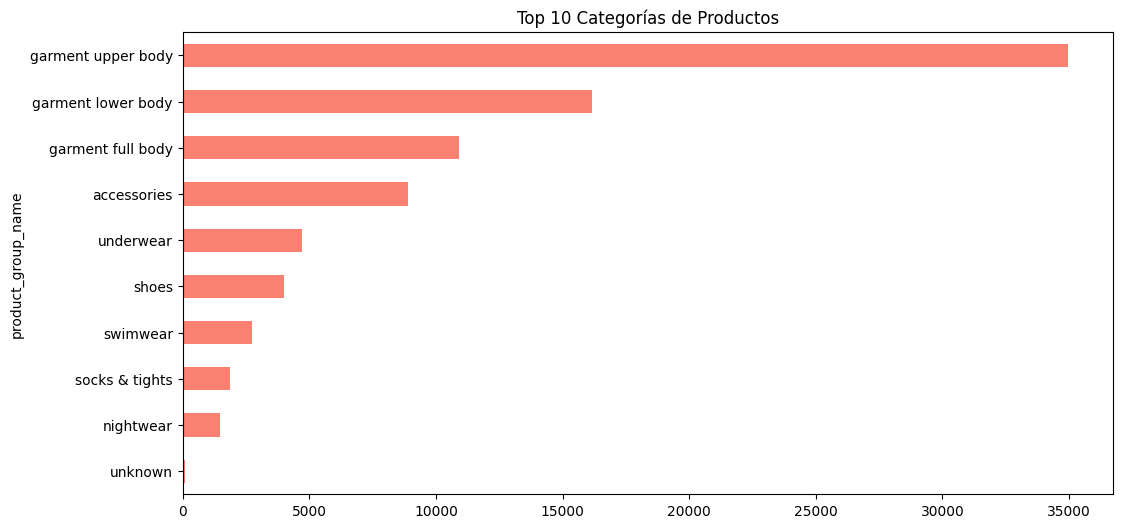

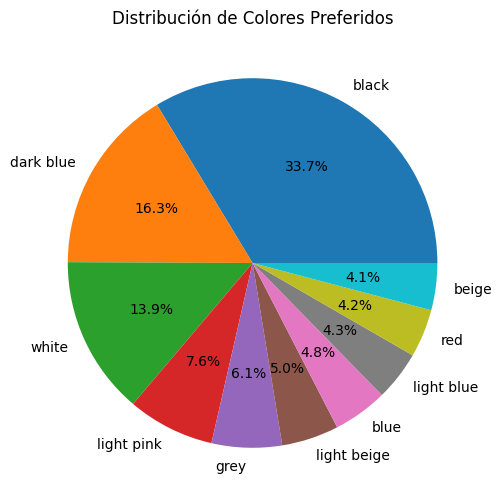

In [7]:
# Top 10 Categorías
plt.figure(figsize=(12, 6))
articles['product_group_name'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Categorías de Productos')
plt.gca().invert_yaxis()
plt.show()

# Colores más vendidos
plt.figure(figsize=(12, 6))
articles['colour_group_name'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución de Colores Preferidos')
plt.show()

In [8]:
# Ticket Promedio (Mean Price)
ticket_promedio = transactions['price'].mean()
print(f"El ticket promedio por transacción es: {ticket_promedio:.4f}")

# Ventas por canal (1=Online, 2=Tienda)
canal_ventas = transactions['sales_channel_id'].value_counts(normalize=True) * 100
print(f"Ventas Online: {canal_ventas[1]:.1f}% | Ventas en Tienda: {canal_ventas[2]:.1f}%")

El ticket promedio por transacción es: 0.0278
Ventas Online: 29.9% | Ventas en Tienda: 70.1%


C:\Users\NoxiePC\AppData\Local\Temp\ipykernel_16196\1118866335.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='price', data=df_merged, estimator='mean', palette='magma')


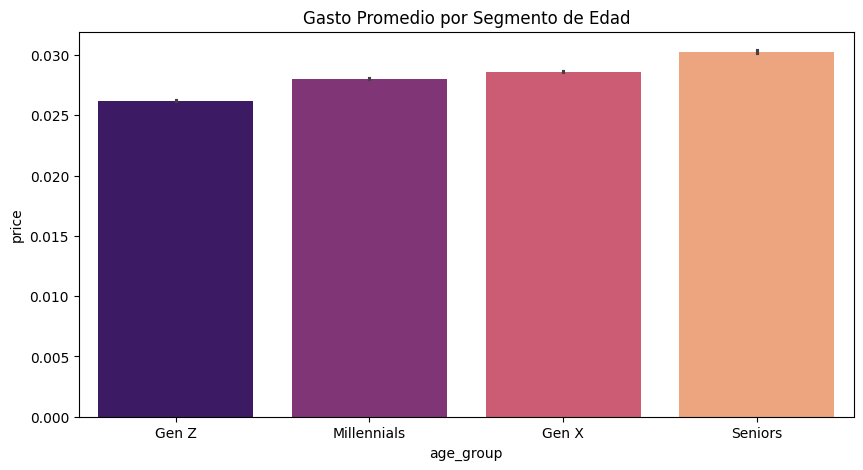

In [9]:
# Crear grupos de edad
customers['age_group'] = pd.cut(customers['age'], 
                                bins=[0, 25, 40, 60, 100], 
                                labels=['Gen Z', 'Millennials', 'Gen X', 'Seniors'])

# Cruzar transacciones con clientes para el análisis de comportamiento
df_merged = transactions.merge(customers[['customer_id', 'age_group', 'age']], on='customer_id', how='left')

# Ver qué grupo de edad gasta más en promedio
plt.figure(figsize=(10, 5))
sns.barplot(x='age_group', y='price', data=df_merged, estimator='mean', palette='magma')
plt.title('Gasto Promedio por Segmento de Edad')
plt.show()

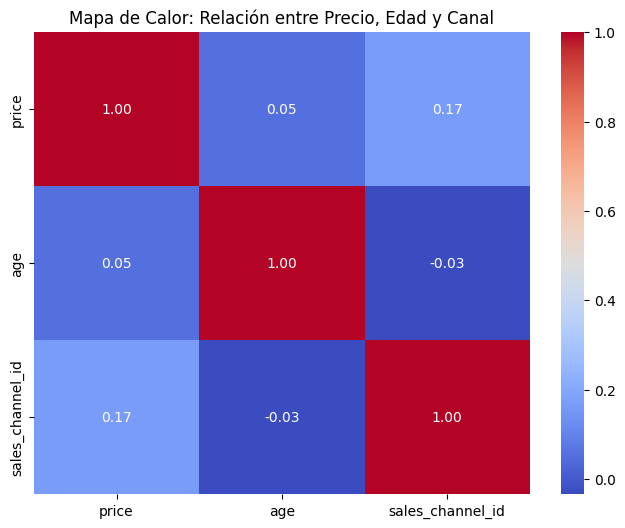

In [10]:
# Seleccionamos variables numéricas clave
corr_matrix = df_merged[['price', 'age', 'sales_channel_id']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# En tu caso, 'price' y 'age' suelen ser las más interesantes de cruzar
plt.title('Mapa de Calor: Relación entre Precio, Edad y Canal')
plt.show()

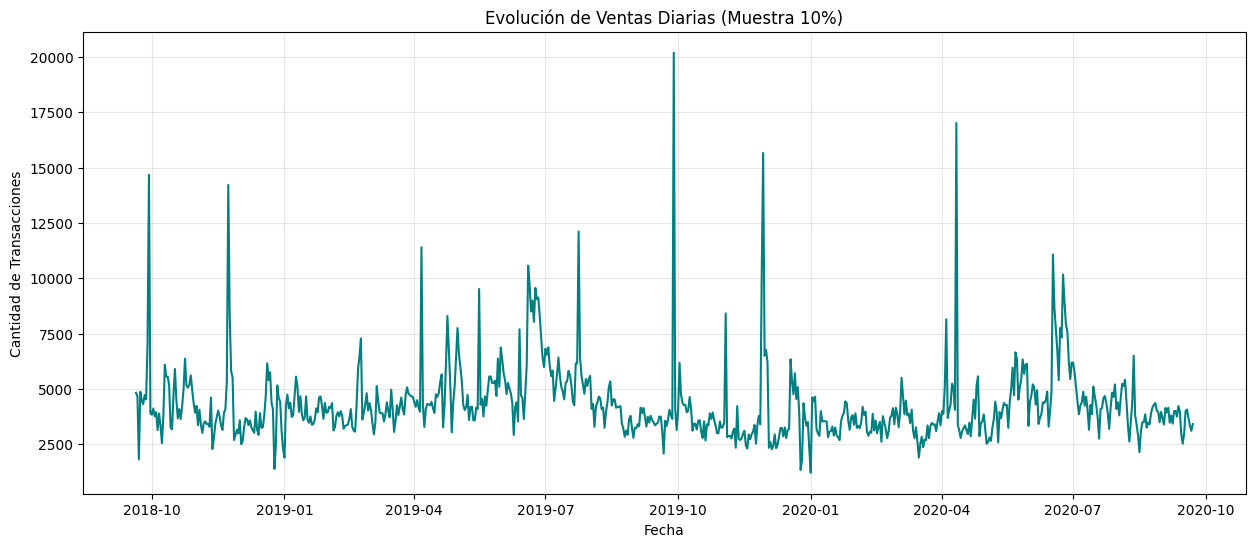

Fechas con mayores picos de ventas:
         t_dat  transaction_count
373 2019-09-28              20188
569 2020-04-11              17012
435 2019-11-29              15659
9   2018-09-29              14680
64  2018-11-23              14216


In [11]:
# Agrupar transacciones por fecha
daily_sales = transactions.groupby('t_dat').size().reset_index(name='transaction_count')

# Graficar la evolución
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_sales, x='t_dat', y='transaction_count', color='teal')
plt.title('Evolución de Ventas Diarias (Muestra 10%)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Transacciones')
plt.grid(True, alpha=0.3)
plt.show()

# Encontrar los 5 picos más altos
top_peaks = daily_sales.sort_values(by='transaction_count', ascending=False).head(5)
print("Fechas con mayores picos de ventas:")
print(top_peaks)

* **28-09-2019** (20,188 transacciones): **Pico Histórico: H&M Member Days**. Representa el punto de máximo engagement de los usuarios ACTIVE en la plataforma.
* **11-04-2020** (17,012 transacciones): **Sábado de Pre-Pascua**. Se observa un incremento significativo impulsado por compras festivas y regalos.
* **29-11-2019** (15,659 transacciones): **Black Friday 2019**. Gran volumen de ventas generado por la campaña de descuentos masivos globales.
* **29-09-2018** (14,680 transacciones): **H&M Member Days 2018**. Coincide con el lanzamiento estratégico de la temporada Otoño/Invierno.
* **23-11-2018** (14,216 transacciones): **Black Friday 2018**. Fecha clave que marca la consolidación de las ventas de fin de año en el primer año de la muestra.

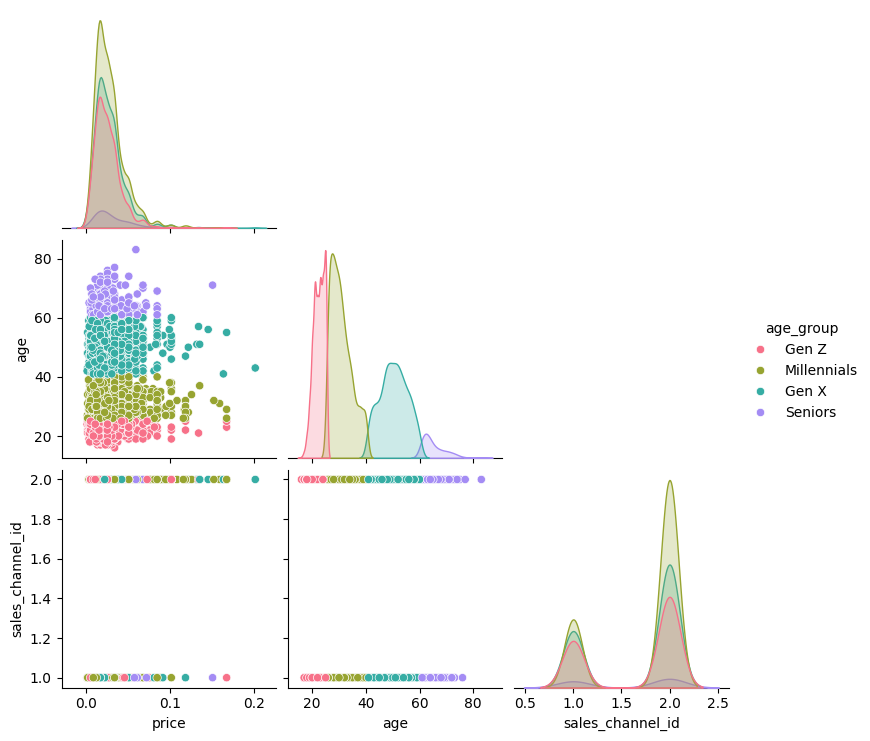

In [12]:
# Seleccionamos solo variables numéricas y el grupo de edad que creamos
v_interes = ['price', 'age', 'sales_channel_id', 'age_group']

# Tomamos una muestra aún más pequeña (ej. 5000 filas) para que el gráfico sea legible y rápido
df_sub = df_merged[v_interes].sample(5000, random_state=42)

# Pairplot con color por segmento de edad
sns.pairplot(df_sub, hue='age_group', palette='husl', corner=True)
plt.show()

In [13]:
# Unimos transacciones con artículos para tener los nombres
top_global = transactions.merge(articles[['article_id', 'prod_name', 'product_group_name']], 
                               on='article_id', how='left')

# Contamos las ventas por nombre de producto
top_10_global = top_global['prod_name'].value_counts().head(10)

print("--- Top 10 Artículos más vendidos (Global) ---")
print(top_10_global)

--- Top 10 Artículos más vendidos (Global) ---
prod_name
jade hw skinny denim trs       16725
luna skinny rw                 14307
timeless midrise brief         12135
tilly (1)                      10495
cat tee.                        8057
simple as that triangle top     7527
shake it in balconette          7462
tilda tank                      6943
despacito                       6729
skinny ankle r.w brooklyn       6639
Name: count, dtype: int64


In [14]:
def get_season(month):
    if month in [12, 1, 2]: return 'Summer' # Hemisferio Sur (ajustar si es Norte)
    elif month in [3, 4, 5]: return 'Autumn'
    elif month in [6, 7, 8]: return 'Winter'
    else: return 'Spring'

# Aplicamos la función
top_global['month'] = top_global['t_dat'].dt.month
top_global['season'] = top_global['month'].apply(get_season)

# Ejemplo: Top 10 en Invierno (Winter)
top_winter = top_global[top_global['season'] == 'Winter']['prod_name'].value_counts().head(10)

print("\n--- Top 10 Artículos más vendidos en Invierno ---")
print(top_winter)


--- Top 10 Artículos más vendidos en Invierno ---
prod_name
timeless midrise brief         4835
cat tee.                       3850
shake it in balconette         3602
tilly (1)                      3327
jade hw skinny denim trs       3250
tilda tank                     3225
simple as that triangle top    2770
simple as that cheeky tanga    2671
nora t-shirt                   2670
luna skinny rw                 2614
Name: count, dtype: int64


In [16]:
# 1. Extraemos el año para separar las temporadas de 2018, 2019 y 2020
top_global['year'] = top_global['t_dat'].dt.year

# 2. Definimos el orden lógico de las estaciones para el reporte
seasons_order = ['Summer', 'Autumn', 'Winter', 'Spring']

print(f"--- Análisis Estacional de Ventas ---")

# 3. Iteramos por año y luego por estación
for year in sorted(top_global['year'].unique()):
    for season in seasons_order:
        # Filtramos el dataframe por año y estación
        df_season = top_global[(top_global['year'] == year) & (top_global['season'] == season)]
        
        # Si hay datos para esa combinación, calculamos el top 10
        if not df_season.empty:
            top_10 = df_season['prod_name'].value_counts().head(10)
            
            print(f"\n>> {season} {year} ({len(df_season):,} transacciones totales)")
            print(top_10)
            print("-" * 30)

--- Análisis Estacional de Ventas ---

>> Summer 2018 (113,899 transacciones totales)
prod_name
luna skinny rw              588
gyda!                       575
jade denim trs              565
jade hw skinny denim trs    440
supreme tights              401
bama                        379
csp grace body              378
scallop 5p socks            304
j bamboo                    303
olga ll pj (j)              298
Name: count, dtype: int64
------------------------------

>> Spring 2018 (322,792 transacciones totales)
prod_name
luna skinny rw           2423
jade denim trs           2327
gyda!                    2290
sirpa                    1908
supreme tights           1621
bama                     1171
latte slacks (1)         1106
matey                    1102
tilly (1)                1076
madison skinny hw (1)    1058
Name: count, dtype: int64
------------------------------

>> Summer 2019 (350,228 transacciones totales)
prod_name
jade hw skinny denim trs     2413
luna skinny rw      

### 1. Los Reyes del Denim (Atemporales)
* **`jade hw skinny denim trs`**: Es el líder indiscutible de ventas. Aparece en el primer puesto en Summer 2019, Spring 2019, Summer 2020 y Spring 2020. Es el producto con mayor resiliencia comercial del dataset.
* **`luna skinny rw`**: El escolta constante. Se mantuvo en el top 2 durante prácticamente todo 2018 y 2019, demostrando que los jeans básicos son el motor de transacciones de la marca.

### 2. El Ascenso del "Confort" (Tendencia 2020)
* **`timeless midrise brief`**: Este artículo no figuraba en los primeros puestos en 2018, pero hacia el Autumn 2020 y Winter 2020 se convirtió en el producto número 1 en ventas.
* **`tilly (1)`**: Al igual que la línea Timeless, este artículo escaló posiciones rápidamente en el último año de registros, desplazando a artículos de denim tradicionales.

### 3. Dinámica Estacional Específica
* **`ozzy denim shorts`**: Aparece con fuerza en el top de Winter 2019 (Junio-Agosto), lo que es un indicador clave para el modelo: aunque el clima sea frío, hay categorías que mantienen un volumen de nicho alto.
* **`simple as that triangle top`**: Domina las transacciones de Autumn 2019 y Winter 2019, sugiriendo campañas de stock muy fuertes en estas categorías de ropa interior/swimwear durante esos periodos.

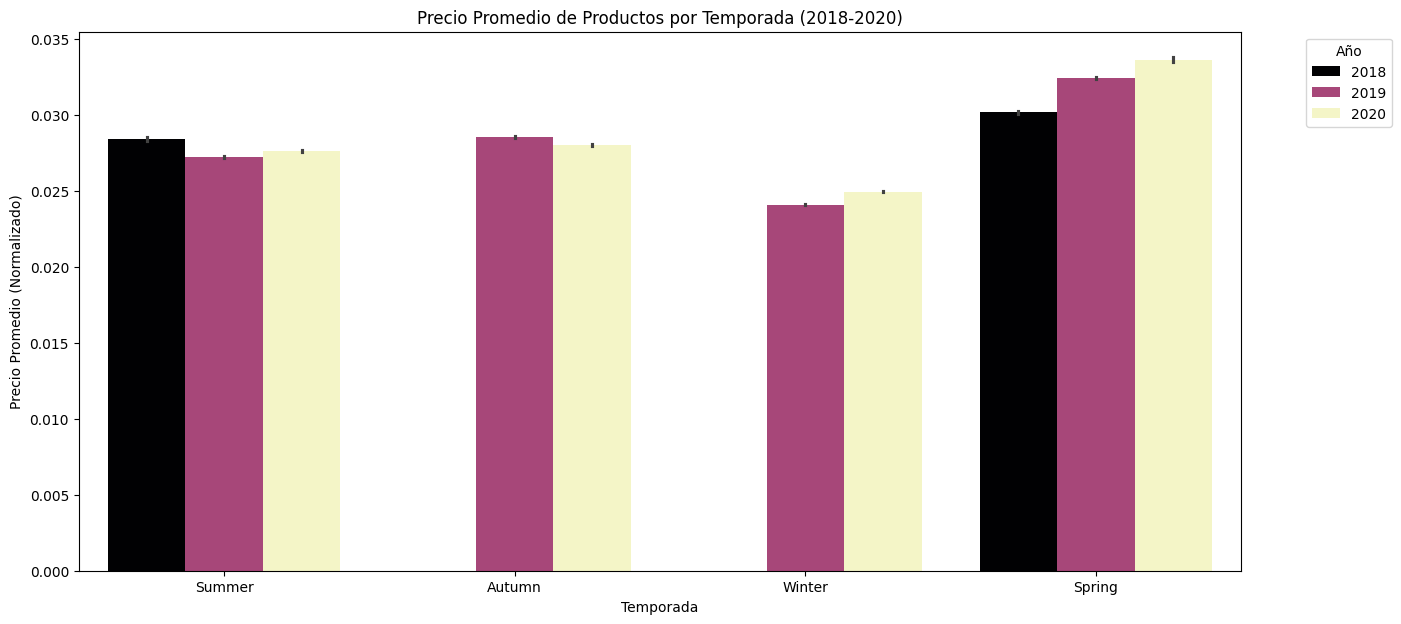

Correlación numérica entre Precio y Temporada: 0.0433


In [17]:
# 1. Agrupamos por año y temporada para ver la evolución del precio promedio
price_seasonal = top_global.groupby(['year', 'season'])['price'].mean().reset_index()

# 2. Visualización de la variación de precios
plt.figure(figsize=(15, 7))

# Gráfico de barras para comparar el promedio
sns.barplot(data=top_global, x='season', y='price', hue='year', 
            order=['Summer', 'Autumn', 'Winter', 'Spring'], palette='magma')

plt.title('Precio Promedio de Productos por Temporada (2018-2020)')
plt.xlabel('Temporada')
plt.ylabel('Precio Promedio (Normalizado)')
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. Cálculo de la correlación numérica (usando códigos para las estaciones)
season_map = {'Summer': 1, 'Autumn': 2, 'Winter': 3, 'Spring': 4}
top_global['season_code'] = top_global['season'].map(season_map)

correlation = top_global[['price', 'season_code']].corr().iloc[0, 1]
print(f"Correlación numérica entre Precio y Temporada: {correlation:.4f}")

### Análisis de Estabilidad de Precios
* **Política de Precios Estable:** H&M mantiene un ticket promedio relativamente constante a lo largo del año, reforzando su posicionamiento de *fast fashion* accesible.
* **Efecto Lanzamiento vs. Liquidación:** Se observa un pico en el ticket promedio durante **Spring** (Septiembre-Noviembre), coincidiendo con la entrada de colecciones pesadas (abrigo) en el hemisferio norte. En contraste, **Winter** (Junio-Agosto) presenta los precios promedio más bajos, reflejando el fuerte impacto de las rebajas y liquidaciones estacionales.

In [18]:
# Unimos el dataframe que tiene las edades con los nombres de los artículos
df_final = df_merged.merge(articles[['article_id', 'prod_name']], on='article_id', how='left')

print("--- Top 5 Artículos por Segmento de Edad ---")

# Iteramos por cada grupo de edad para ver sus favoritos
for age_g in ['Gen Z', 'Millennials', 'Gen X', 'Seniors']:
    print(f"\n>> {age_g}")
    # Filtramos por el grupo y contamos los artículos
    top_items = df_final[df_final['age_group'] == age_g]['prod_name'].value_counts().head(5)
    print(top_items)
    print("-" * 30)

--- Top 5 Artículos por Segmento de Edad ---

>> Gen Z
prod_name
jade hw skinny denim trs       6428
tilda tank                     3771
timeless midrise brief         3680
luna skinny rw                 3176
simple as that triangle top    2937
Name: count, dtype: int64
------------------------------

>> Millennials
prod_name
luna skinny rw              5733
jade hw skinny denim trs    5312
timeless midrise brief      4857
tilly (1)                   4268
cat tee.                    3476
Name: count, dtype: int64
------------------------------

>> Gen X
prod_name
luna skinny rw              4857
jade hw skinny denim trs    4692
timeless midrise brief      3407
tilly (1)                   2964
pluto rw slacks (1)         2781
Name: count, dtype: int64
------------------------------

>> Seniors
prod_name
skinny ankle r.w brooklyn    613
tilly (1)                    551
primo slacks                 544
luna skinny rw               541
calista (1)                  529
Name: count, dtype: i

### Insights de Segmentación por Edad (Feature Engineering)

El cruce de productos más vendidos con los rangos etarios revela que una estrategia de recomendación genérica sería ineficiente. Se observan los siguientes patrones clave:

* **El salto generacional del Denim:** El artículo `jade hw skinny denim trs` es el rey indiscutido de la **Gen Z** (6,428 transacciones) y muy fuerte en **Millennials** (5,312 transacciones). Sin embargo, desaparece por completo del Top 5 en el segmento de **Seniors**.
* **Transición hacia la formalidad y el confort:** A medida que avanzamos hacia la **Gen X** y los **Seniors**, ingresan al Top 5 artículos como `pluto rw slacks (1)` y `primo slacks`. Los pantalones de corte más formal o suelto ("slacks") reemplazan a las prendas más juveniles de la Gen Z, como el `simple as that triangle top` o el `tilda tank`.
* **Nichos específicos por edad:** El segmento **Seniors** tiene un claro favorito exclusivo: el `skinny ankle r.w brooklyn` (613 transacciones), un artículo que no logra entrar en el ranking de ninguna de las otras tres generaciones.
* **Los comodines transversales:** Las prendas `luna skinny rw` y `tilly (1)` demuestran tener un atractivo universal, logrando mantenerse en los primeros puestos a través de múltiples brechas generacionales.